#Loading Libraries

In [44]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import warnings
import numpy as np
import subprocess
import pandas as pd
import numpy as np
from sklearn.metrics import precision_score, f1_score, balanced_accuracy_score, recall_score
from sklearn import metrics
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
#from sklearn.feature_extraction.text import CountVectorizer  #DT does not take strings as input for the model fit step....
from IPython.display import Image
#import pydotplus as pydot
from sklearn import tree
warnings.filterwarnings('ignore')
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


# **Date Cleaning and Loading**

**cleaning and doing one hot encoding**

In [45]:
url = 'https://raw.githubusercontent.com/finsaccount/Intrusion-Detection-System-Machine-Learning/refs/heads/main/data%202.csv'
data = pd.read_csv(url)
labels_dict={'attack':1, 'benign':0}
data['label2'] = data['label2'].map(labels_dict)
data = data.dropna()
data = data.drop('label', axis=1)
data.head()


,network_ttl_avg,network_ttl_max,network_ttl_min,network_ttl_std_deviation,network_header-length_avg,network_header-length_max,network_header-length_min,network_header-length_std_deviation,network_fragmented-packets,network_fragmentation-score,...,network_packets_dst_count,network_interval-packets,log_messages_count,log_data-ranges_avg,log_data-ranges_max,log_data-ranges_min,log_data-ranges_std_deviation,log_data-types_count,timeDurationInSeconds,label2
0,63.000000,64.0,62.0,1.000017,20.0,20.0,20.0,0.0,0,0,...,14750,3108.335228,29500,0,0,0,0,0,10,1
1,62.999877,64.0,61.0,1.000246,20.0,20.0,20.0,0.0,0,0,...,4065,914.745196,8133,0,0,0,0,0,10,1
2,62.675676,64.0,62.0,0.949158,20.0,20.0,20.0,0.0,0,0,...,98,30.766254,148,0,0,0,0,0,10,1
3,63.000000,64.0,62.0,1.000023,20.0,20.0,20.0,0.0,0,0,...,11080,2500.940731,22160,0,0,0,0,0,10,1
5,62.857143,64.0,62.0,1.069045,20.0,20.0,20.0,0.0,0,0,...,4,0.707193,7,0,0,0,0,0,10,1


In [46]:
X = data.drop('label2', axis=1)
Y = data.pop('label2')
x_train, x_test, y_train, y_test = train_test_split(X, Y,
                                                    test_size=0.3,
                                                    random_state=123,
                                                    shuffle=True)
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.fit_transform(x_test)

## Individual Model

**Support Vector Machine**

              precision    recall  f1-score   support

           0       0.96      0.99      0.97       214
           1       0.99      0.97      0.98       278

    accuracy                           0.98       492
   macro avg       0.98      0.98      0.98       492
weighted avg       0.98      0.98      0.98       492

Precision 0.9676258992805755
F1 0.9799635701275046
Recall 0.992619926199262
Balanced Accuracy 0.9759479721494048


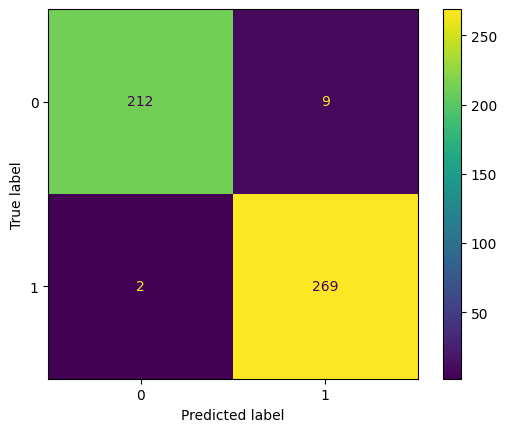

In [47]:
from sklearn.svm import SVC
svm_model = SVC(kernel='rbf', C=100, gamma = 0.01)
svm_model.fit(x_train_scaled, y_train)
predictionSVM = svm_model.predict(x_test_scaled)
cm = confusion_matrix(y_test, predictionSVM, labels=y_test.unique())
print(classification_report(predictionSVM, y_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=y_test.unique())
disp.plot()
print(f"Precision {precision_score(y_test, predictionSVM)}")
print(f"F1 {f1_score(y_test, predictionSVM)}")
print(f"Recall {recall_score(y_test, predictionSVM)}")
print(f"Balanced Accuracy {balanced_accuracy_score(y_test, predictionSVM)}")

**KNN**

In [48]:
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(x_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


              precision    recall  f1-score   support

           0       0.94      0.98      0.96       213
           1       0.98      0.95      0.97       279

    accuracy                           0.96       492
   macro avg       0.96      0.96      0.96       492
weighted avg       0.96      0.96      0.96       492

Precision 0.953405017921147
F1 0.9672727272727273
Recall 0.981549815498155
Balanced Accuracy 0.9613631430431951


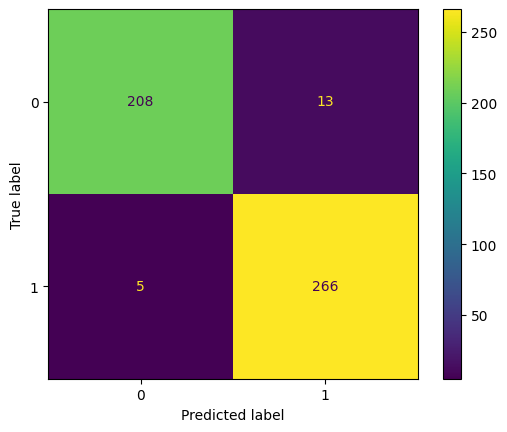

In [49]:
predictionKNN = knn_model.predict(x_test_scaled)
cm = confusion_matrix(y_test, predictionKNN, labels=y_test.unique())
print(classification_report(predictionKNN, y_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=y_test.unique())
disp.plot()
print(f"Precision {precision_score(y_test, predictionKNN)}")
print(f"F1 {f1_score(y_test, predictionKNN)}")
print(f"Recall {recall_score(y_test, predictionKNN)}")
print(f"Balanced Accuracy {balanced_accuracy_score(y_test, predictionKNN)}")

**KNN: Train vs Test Accuracy for K = 5 to 15**

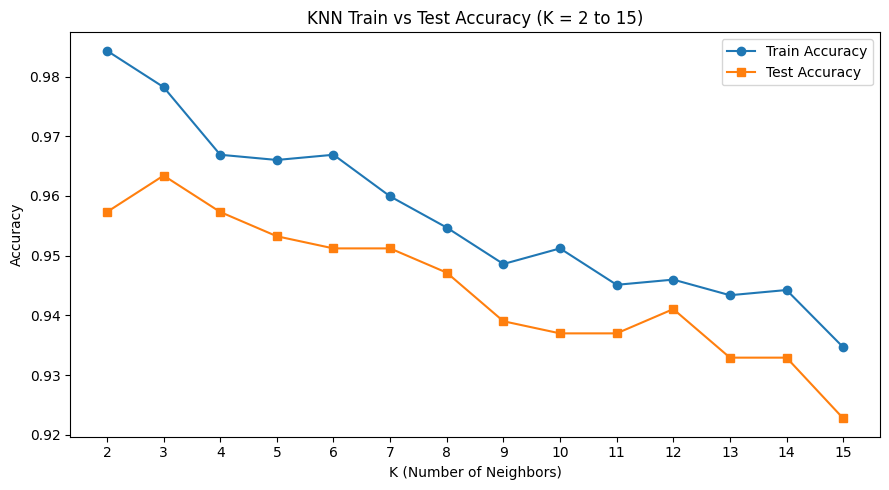

In [50]:
from sklearn.neighbors import KNeighborsClassifier

k_values = range(2, 16)
train_accuracies = []
test_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train_scaled, y_train)
    train_accuracies.append(accuracy_score(y_train, knn.predict(x_train_scaled)))
    test_accuracies.append(accuracy_score(y_test, knn.predict(x_test_scaled)))

plt.figure(figsize=(9, 5))
plt.plot(list(k_values), train_accuracies, marker='o', label='Train Accuracy')
plt.plot(list(k_values), test_accuracies, marker='s', label='Test Accuracy')
plt.xticks(list(k_values))
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('Accuracy')
plt.title('KNN Train vs Test Accuracy (K = 2 to 15)')
plt.legend()
plt.tight_layout()
plt.show()

## KNN Hyperparameter Selection: k = 3

Analysis of the train/test accuracy sweep (K = 2-15) shows that **k = 3** maximizes test accuracy at approximately **96%** while maintaining a train accuracy of **~97.6%**. The generalization gap (train - test) remains small at k = 3; beyond this point test accuracy trends downward -- a clear sign of underfitting as neighbourhood size grows. All subsequent analyses, including the Stacking Ensemble, use **k = 3** as the KNN component's hyperparameter.

**Random Forest**

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       221
           1       0.99      0.99      0.99       271

    accuracy                           0.99       492
   macro avg       0.99      0.99      0.99       492
weighted avg       0.99      0.99      0.99       492

Precision 0.988929889298893
F1 0.988929889298893
Recall 0.988929889298893
Balanced Accuracy 0.9876776143327044


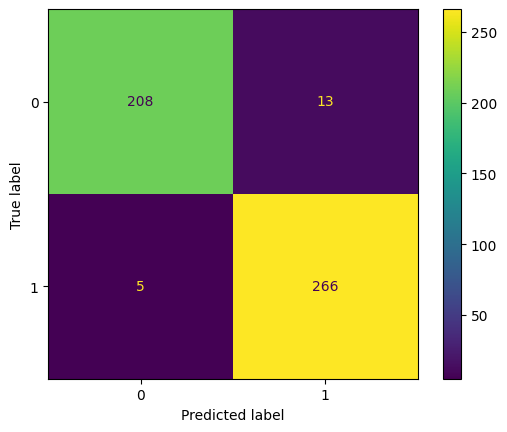

In [51]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(x_train, y_train)
predictionTree = rf_model.predict(x_test)
print(classification_report(predictionTree, y_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=y_test.unique())
disp.plot()
print(f"Precision {precision_score(y_test, predictionTree)}")
print(f"F1 {f1_score(y_test, predictionTree)}")
print(f"Recall {recall_score(y_test, predictionTree)}")
print(f"Balanced Accuracy {balanced_accuracy_score(y_test, predictionTree)}")

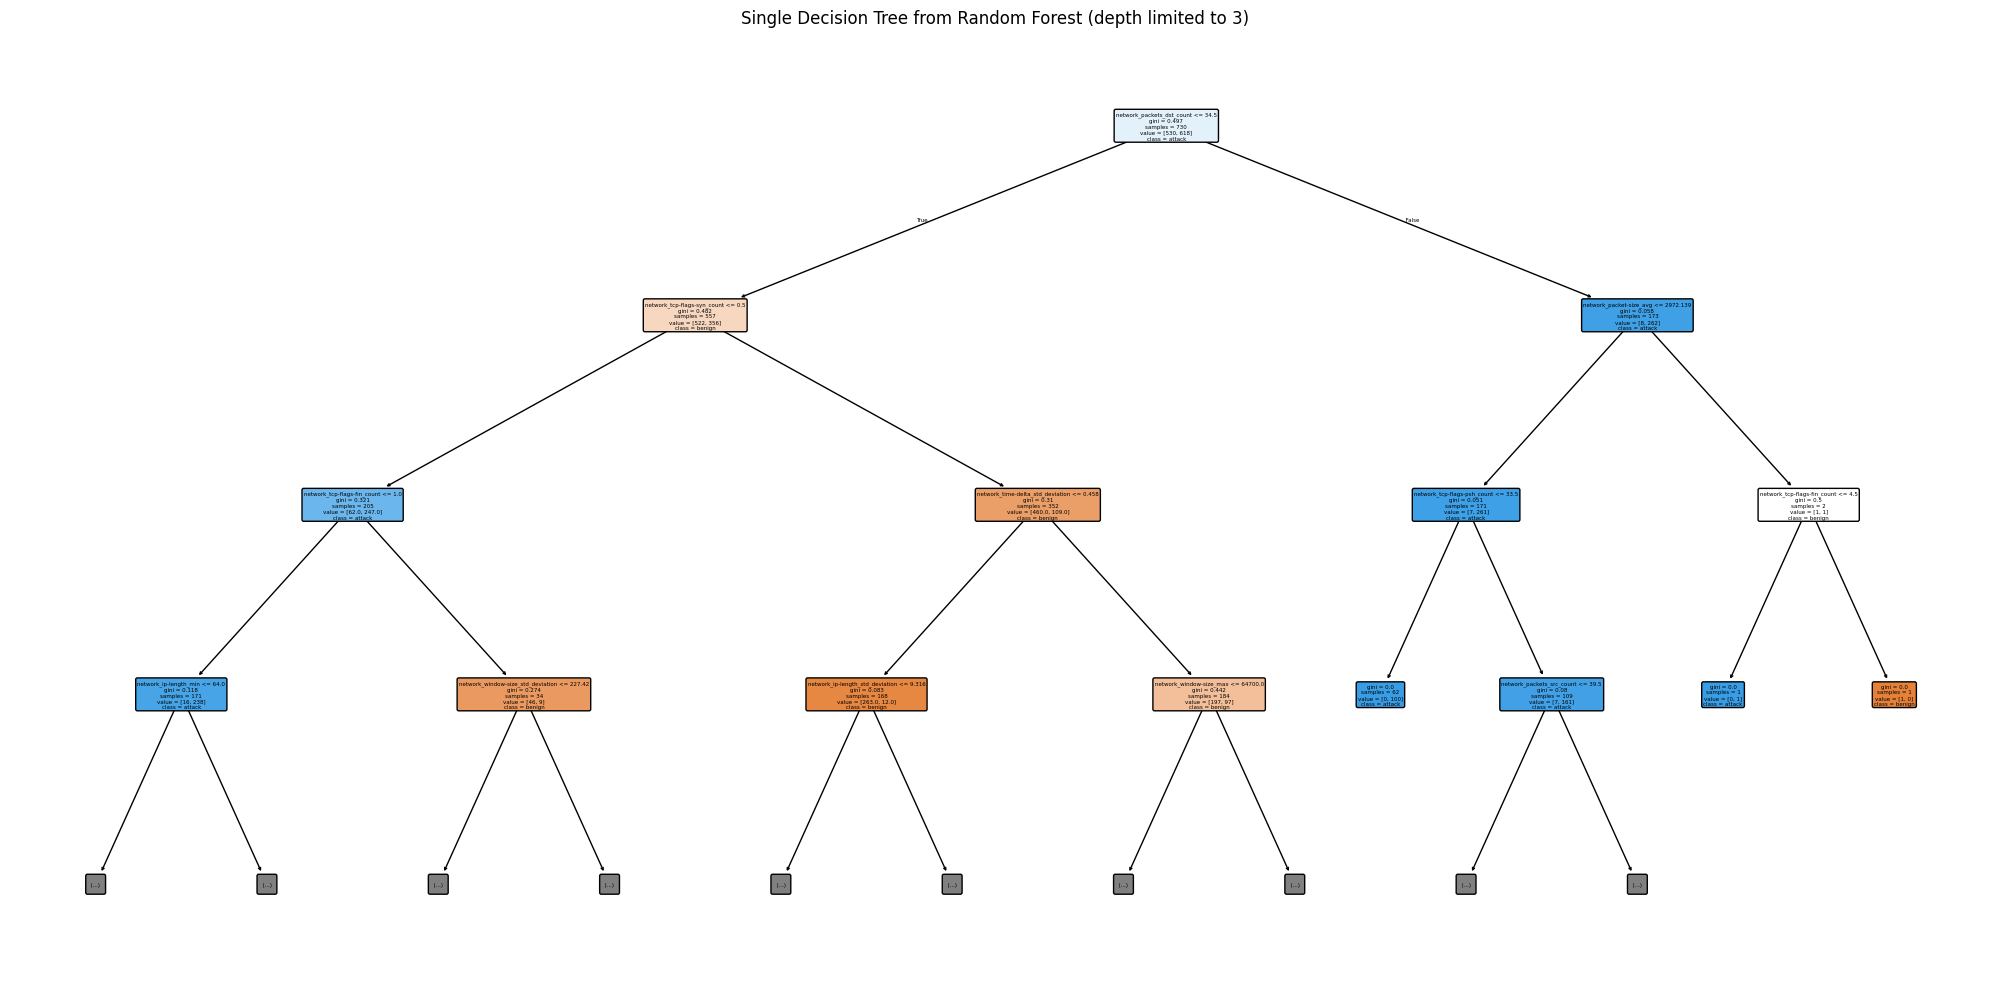

In [52]:
from sklearn.tree import plot_tree

rf_model.fit(x_train, y_train)
individual_tree = rf_model.estimators_[0]

fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(individual_tree,
          feature_names=list(x_train.columns),
          class_names=["benign", "attack"],
          filled=True, rounded=True,
          max_depth=3, ax=ax)
ax.set_title("Single Decision Tree from Random Forest (depth limited to 3)")
plt.tight_layout()
plt.show()


# Voting Classifier

Classification Report for Voting SOFT
              precision    recall  f1-score   support

           0       0.99      0.95      0.97       221
           1       0.96      0.99      0.98       271

    accuracy                           0.98       492
   macro avg       0.98      0.97      0.98       492
weighted avg       0.98      0.98      0.98       492

Precision 0.96415770609319
F1 0.9781818181818182
Recall 0.992619926199262
Balanced Accuracy 0.9736855287104907


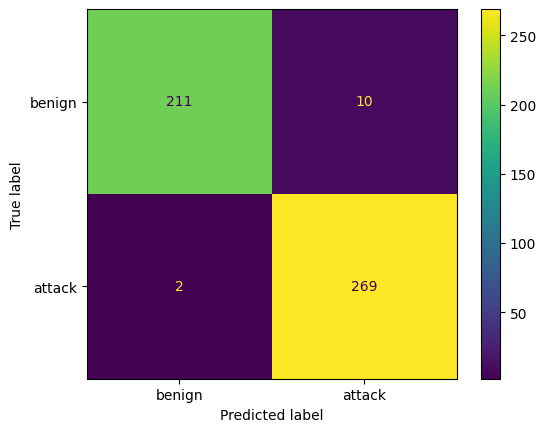

In [53]:
from sklearn.ensemble import VotingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

svm_model = SVC(kernel='rbf', C=100, gamma=0.01, probability=True)
knn_model = KNeighborsClassifier(n_neighbors=5)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
voting_clf = VotingClassifier(
    estimators=[('svm', svm_model), ('knn', knn_model), ('rf', rf_model)],
    voting='soft'
)
voting_clf.fit(x_train_scaled, y_train)
predictions = voting_clf.predict(x_test_scaled)
print("Classification Report for Voting SOFT")
print(classification_report(y_test, predictions))
print(f"Precision {precision_score(y_test, predictions)}")
print(f"F1 {f1_score(y_test, predictions)}")
print(f"Recall {recall_score(y_test, predictions)}")
print(f"Balanced Accuracy {balanced_accuracy_score(y_test, predictions)}")
cm = confusion_matrix(y_test, predictions, labels=y_test.unique())
label_names = [name for name, val in sorted(labels_dict.items(), key=lambda item: item[1])]
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot();

Classification Report for Voting HARD
              precision    recall  f1-score   support

           0       0.99      0.95      0.97       221
           1       0.96      0.99      0.98       271

    accuracy                           0.98       492
   macro avg       0.98      0.97      0.98       492
weighted avg       0.98      0.98      0.98       492

Precision 0.96415770609319
F1 0.9781818181818182
Recall 0.992619926199262
Balanced Accuracy 0.9736855287104907


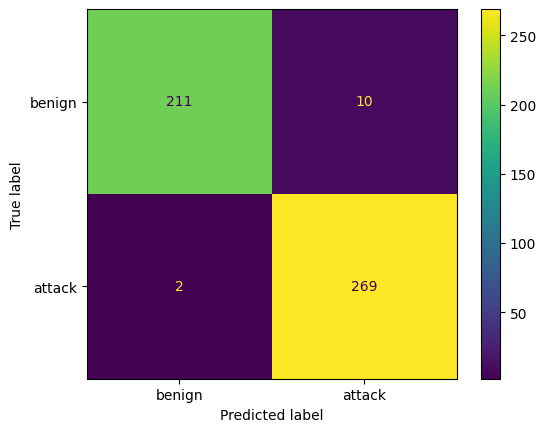

In [54]:
svm_model = SVC(kernel='rbf', C=100, gamma=0.01, probability=True)
knn_model = KNeighborsClassifier(n_neighbors=5)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
voting_clf = VotingClassifier(
    estimators=[('svm', svm_model), ('knn', knn_model), ('rf', rf_model)],
    voting='hard'
)
voting_clf.fit(x_train_scaled, y_train)
predictions = voting_clf.predict(x_test_scaled)
print("Classification Report for Voting HARD")
print(classification_report(y_test, predictions))
print(f"Precision {precision_score(y_test, predictions)}")
print(f"F1 {f1_score(y_test, predictions)}")
print(f"Recall {recall_score(y_test, predictions)}")
print(f"Balanced Accuracy {balanced_accuracy_score(y_test, predictions)}")
cm = confusion_matrix(y_test, predictions, labels=y_test.unique())
label_names = [name for name, val in sorted(labels_dict.items(), key=lambda item: item[1])]
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot();

# Stacking Classifier

In [55]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline

estimators = [
    ('svm', make_pipeline(StandardScaler(), SVC(kernel='rbf', C=100, gamma=0.01, probability=True))),
    ('knn', make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=3))),
    ('rf', RandomForestClassifier(n_estimators=100))
]
stack_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    cv=5
)
stack_clf.fit(x_train_scaled,y_train)

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('svm', ...), ('knn', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",LogisticRegression()
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",5
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'auto'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The 

Classification Report for Stacking Ensemble
              precision    recall  f1-score   support

           0       0.99      0.95      0.97       221
           1       0.96      0.99      0.98       271

    accuracy                           0.98       492
   macro avg       0.98      0.97      0.98       492
weighted avg       0.98      0.98      0.98       492

Precision 0.96415770609319
F1 0.9781818181818182
Recall 0.992619926199262
Balanced Accuracy 0.9736855287104907


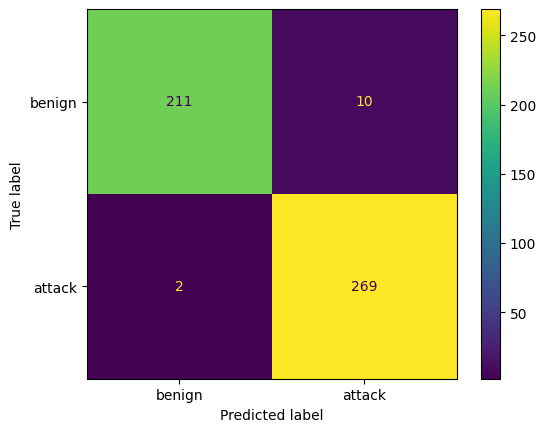

In [56]:
predictionsStack = stack_clf.predict(x_test_scaled)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("Classification Report for Stacking Ensemble")
print(classification_report(y_test, predictionsStack))
print(f"Precision {precision_score(y_test, predictionsStack)}")
print(f"F1 {f1_score(y_test, predictionsStack)}")
print(f"Recall {recall_score(y_test, predictionsStack)}")
print(f"Balanced Accuracy {balanced_accuracy_score(y_test, predictionsStack)}")

#  'attack': 1, 'benign': 0
label_names = [name for name, val in sorted(labels_dict.items(), key=lambda item: item[1])]

cm = confusion_matrix(y_test, predictionsStack, labels=y_test.unique())
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot()


# Stacking Ensemble: Advanced Evaluation

The following cells evaluate the diversity of base-model predictions, compare generalisation
via 10-fold cross-validation, visualise ROC curves, and rank feature importance through
permutation testing. All plots use a consistent `seaborn-v0_8` aesthetic.


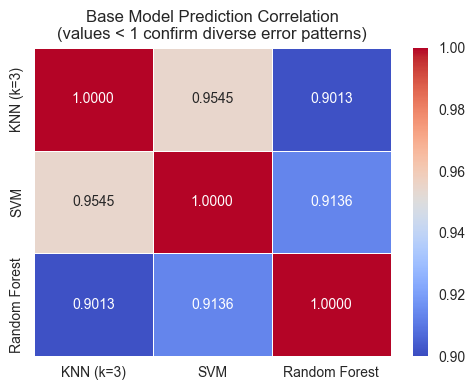

In [57]:
plt.style.use("seaborn-v0_8")

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Fit individual base models with optimal k=3
knn_base = KNeighborsClassifier(n_neighbors=3)
svm_base = SVC(kernel="rbf", C=100, gamma=0.01, probability=True)
rf_base  = RandomForestClassifier(n_estimators=100, random_state=42)

knn_base.fit(x_train_scaled, y_train)
svm_base.fit(x_train_scaled, y_train)
rf_base.fit(x_train_scaled, y_train)

pred_knn = knn_base.predict(x_test_scaled)
pred_svm = svm_base.predict(x_test_scaled)
pred_rf  = rf_base.predict(x_test_scaled)

pred_df = pd.DataFrame({"KNN (k=3)": pred_knn, "SVM": pred_svm, "Random Forest": pred_rf})

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(pred_df.corr(), annot=True, fmt=".4f", cmap="coolwarm",
            vmin=0.9, vmax=1.0, ax=ax, linewidths=0.5)
ax.set_title("Base Model Prediction Correlation\n(values < 1 confirm diverse error patterns)")
plt.tight_layout()
plt.show()


## Cross-Validation Comparison (10-Fold)

Boxplots of 10-fold CV accuracy show the spread and median performance of each base model
versus the full Stacking Ensemble, confirming that stacking reduces variance as well as improving mean accuracy.


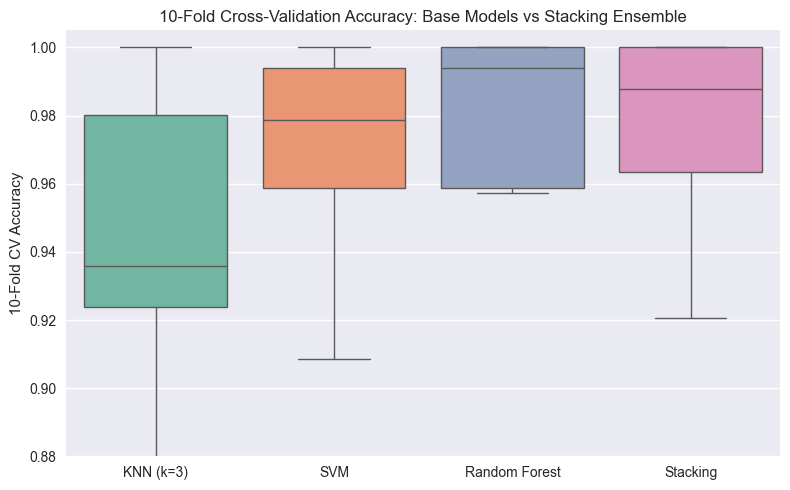

Mean CV Accuracies:
KNN (k=3)        0.930488
SVM              0.971951
Random Forest    0.970122
Stacking         0.975000


In [58]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

cv_results = {
    "KNN (k=3)": cross_val_score(
        make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=3)),
        X, Y, cv=10, scoring="accuracy"),
    "SVM": cross_val_score(
        make_pipeline(StandardScaler(), SVC(kernel="rbf", C=100, gamma=0.01)),
        X, Y, cv=10, scoring="accuracy"),
    "Random Forest": cross_val_score(
        RandomForestClassifier(n_estimators=100, random_state=42),
        X, Y, cv=10, scoring="accuracy"),
    "Stacking": cross_val_score(
        StackingClassifier(
            estimators=[
                ("svm", make_pipeline(StandardScaler(), SVC(kernel="rbf", C=100, gamma=0.01, probability=True))),
                ("knn", make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=3))),
                ("rf",  RandomForestClassifier(n_estimators=100, random_state=42))
            ],
            final_estimator=LogisticRegression(), cv=5
        ),
        X, Y, cv=10, scoring="accuracy")
}

cv_df = pd.DataFrame(cv_results)

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=cv_df, ax=ax, palette="Set2")
ax.set_ylabel("10-Fold CV Accuracy")
ax.set_title("10-Fold Cross-Validation Accuracy: Base Models vs Stacking Ensemble")
ax.set_ylim(0.88, 1.005)
plt.tight_layout()
plt.show()

print("Mean CV Accuracies:")
print(cv_df.mean().to_string())


## ROC / AUC Curves

A single plot of ROC curves for all three base models and the Stacking Ensemble illustrates
the trade-off between sensitivity (TPR) and specificity (1 - FPR).


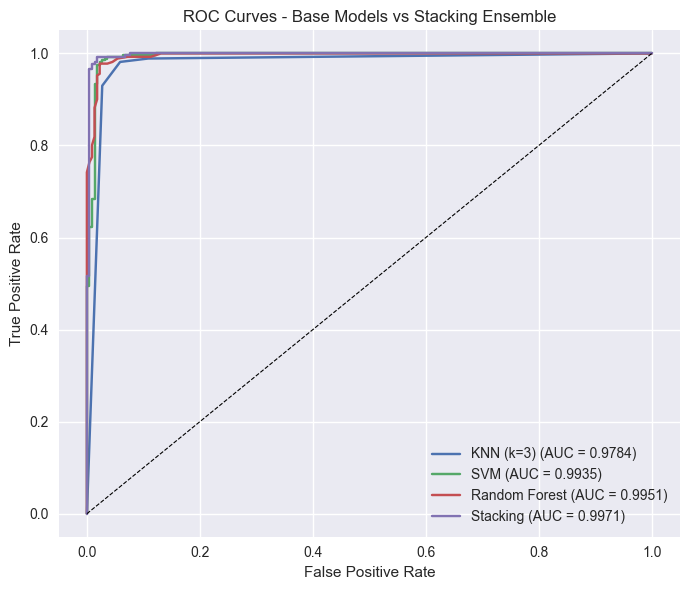

In [59]:
from sklearn.metrics import roc_curve, auc

roc_models = {
    "KNN (k=3)":     knn_base,
    "SVM":           svm_base,
    "Random Forest": rf_base,
    "Stacking":      stack_clf,
}

fig, ax = plt.subplots(figsize=(7, 6))
for name, model in roc_models.items():
    proba = model.predict_proba(x_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.4f})")

ax.plot([0, 1], [0, 1], "k--", linewidth=0.8)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves - Base Models vs Stacking Ensemble")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


## Permutation Feature Importance

Permutation importance measures how much test accuracy drops when each feature is randomly shuffled.
Comparing the top-15 features across all four models reveals which signals each model type relies on,
and why combining them in a Stacking Ensemble captures a broader view of the traffic data.


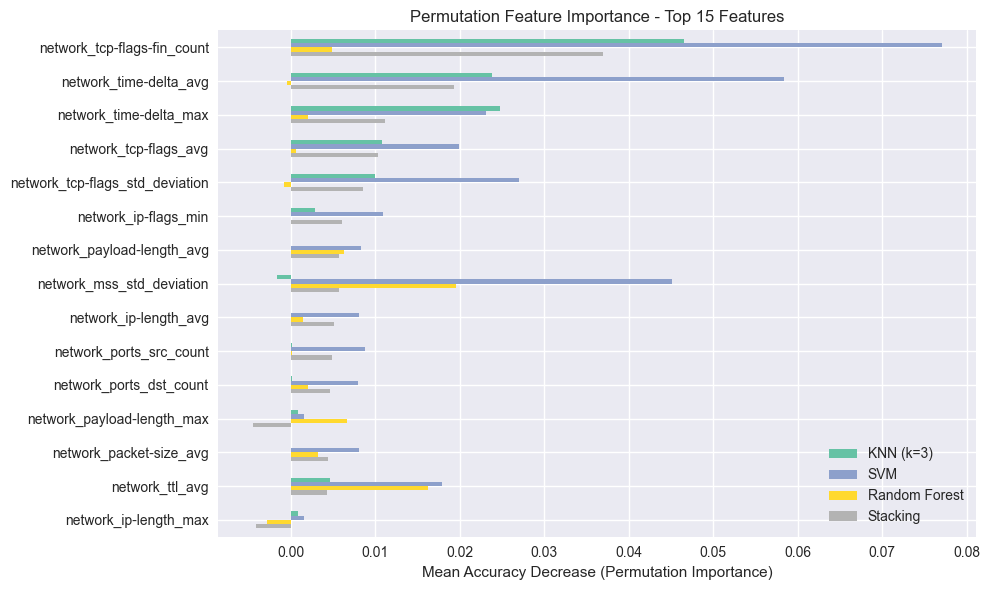

In [60]:
from sklearn.inspection import permutation_importance

pi_results = {}
for name, model in roc_models.items():
    pi = permutation_importance(
        model, x_test_scaled, y_test,
        n_repeats=10, random_state=42, scoring="accuracy"
    )
    pi_results[name] = pi.importances_mean

pi_df = pd.DataFrame(pi_results, index=X.columns)

top_features = pi_df["Stacking"].abs().nlargest(15).index
pi_top = pi_df.loc[top_features]

fig, ax = plt.subplots(figsize=(10, 6))
pi_top.plot(kind="barh", ax=ax, colormap="Set2")
ax.set_xlabel("Mean Accuracy Decrease (Permutation Importance)")
ax.set_title("Permutation Feature Importance - Top 15 Features")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


# Bagging Classifier

In [61]:
from sklearn.ensemble import BaggingClassifier
bag_dt = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=50)
bag_dt.fit(x_train,y_train)
print(classification_report(y_test, bag_dt.predict(x_test)))

              precision    recall  f1-score   support

           0       0.98      0.96      0.97       221
           1       0.97      0.98      0.98       271

    accuracy                           0.97       492
   macro avg       0.97      0.97      0.97       492
weighted avg       0.97      0.97      0.97       492



In [62]:
bag_knn = BaggingClassifier(estimator=KNeighborsClassifier(n_neighbors=5), n_estimators=50)
bag_knn.fit(x_train, y_train)
print(classification_report(y_test, bag_knn.predict(x_test)))

              precision    recall  f1-score   support

           0       0.99      0.90      0.94       221
           1       0.92      0.99      0.95       271

    accuracy                           0.95       492
   macro avg       0.95      0.94      0.95       492
weighted avg       0.95      0.95      0.95       492



In [65]:
bag_svm = BaggingClassifier(estimator=SVC(), n_estimators=10)
bag_svm.fit(x_train, y_train)
print(classification_report(y_test, bag_knn.predict(x_test)))

              precision    recall  f1-score   support

           0       0.99      0.90      0.94       221
           1       0.92      0.99      0.95       271

    accuracy                           0.95       492
   macro avg       0.95      0.94      0.95       492
weighted avg       0.95      0.95      0.95       492



# Summary

The Stacking Classifier worked best.
It produced a model with an accuracy of 98%